Install Required Dependencies


In [1]:
!pip install -q pycocotools
!pip install -q timm
!pip install -q torchinfo
!pip install -q albumentations
!pip install -q opencv-python
!pip install -q scikit-learn
!pip install -q tqdm
!pip install -q seaborn

Import Required Libraries

In [2]:
# Standard Libraries
import os
import json
import random
import shutil
import warnings
from pathlib import Path

# Numerical Computing
import numpy as np
import pandas as pd

# Computer Vision
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress Bar
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

# Vision Transformer
import timm

# COCO
from pycocotools.coco import COCO

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# SVM
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Miscellaneous
from torchinfo import summary

warnings.filterwarnings("ignore")

In [11]:
# Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random Seed : {SEED}")

Random Seed : 42


In [5]:
#GPU Information
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("Device Information")
print("=" * 60)

print(f"Device          : {device}")

if torch.cuda.is_available():

    print(f"GPU Name        : {torch.cuda.get_device_name(0)}")
    print(f"GPU Count       : {torch.cuda.device_count()}")

    total_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3

    print(f"GPU Memory      : {total_memory:.2f} GB")

else:

    print("Running on CPU")

Device Information
Device          : cuda
GPU Name        : Tesla T4
GPU Count       : 1
GPU Memory      : 14.56 GB


In [12]:
#Extract Dataset from ZIP File
from zipfile import ZipFile
import os

#ZIP file path
ZIP_PATH = "/content/drive/MyDrive/Suspicious_behavior/data/Suspicious Behavior.v3i.coco.zip"

# Destination folder
EXTRACT_PATH = "/content/drive/MyDrive/Suspicious_behavior/data"

#Check whether already extracted
folder_name = os.path.join(EXTRACT_PATH, "Suspicious Behavior.v3i.coco")

if os.path.exists(folder_name):
    print("Dataset is already extracted.")
else:
    print("Extracting dataset...")

    with ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

    print("Dataset extracted successfully!")

print("\nContents of data folder:")
print(os.listdir(EXTRACT_PATH))

Extracting dataset...
Dataset extracted successfully!

Contents of data folder:
['Suspicious Behavior.v3i.coco.zip', 'README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid']


In [14]:
# Project Paths
PROJECT_DIR = "/content/drive/MyDrive/Suspicious_behavior/data"

TRAIN_DIR = os.path.join(PROJECT_DIR, "train")
VALID_DIR = os.path.join(PROJECT_DIR, "valid")
TEST_DIR  = os.path.join(PROJECT_DIR, "test")

TRAIN_JSON = os.path.join(TRAIN_DIR, "_annotations.coco.json")
VALID_JSON = os.path.join(VALID_DIR, "_annotations.coco.json")
TEST_JSON  = os.path.join(TEST_DIR, "_annotations.coco.json")

CLASSIFICATION_DIR = os.path.join(
    PROJECT_DIR,
    "classification_dataset"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "saved_models"
)

RESULT_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

os.makedirs(CLASSIFICATION_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Project Path Configured Successfully.")

Project Path Configured Successfully.


In [15]:
#Experiment Configuration

CONFIG = {

    "IMAGE_SIZE": 224,

    "BATCH_SIZE": 32,

    "EPOCHS": 30,

    "LEARNING_RATE": 1e-4,

    "NUM_WORKERS": 2,

    "NUM_CLASSES": 3,

    "CLASS_NAMES": [
        "Fight",
        "Normal",
        "Poster"
    ],

    "DEVICE": device,

    "SEED": SEED

}

print("=" * 60)

for key, value in CONFIG.items():
    print(f"{key:<20}: {value}")

print("=" * 60)

IMAGE_SIZE          : 224
BATCH_SIZE          : 32
EPOCHS              : 30
LEARNING_RATE       : 0.0001
NUM_WORKERS         : 2
NUM_CLASSES         : 3
CLASS_NAMES         : ['Fight', 'Normal', 'Poster']
DEVICE              : cuda
SEED                : 42


In [16]:
#Verify Dataset Structure

print("=" * 60)

print("Checking Dataset Structure")

print("=" * 60)

print("Train JSON Exists :", os.path.exists(TRAIN_JSON))
print("Valid JSON Exists :", os.path.exists(VALID_JSON))
print("Test JSON Exists  :", os.path.exists(TEST_JSON))

print()

print("Train Folder :", TRAIN_DIR)
print("Valid Folder :", VALID_DIR)
print("Test Folder  :", TEST_DIR)

Checking Dataset Structure
Train JSON Exists : True
Valid JSON Exists : True
Test JSON Exists  : True

Train Folder : /content/drive/MyDrive/Suspicious_behavior/data/train
Valid Folder : /content/drive/MyDrive/Suspicious_behavior/data/valid
Test Folder  : /content/drive/MyDrive/Suspicious_behavior/data/test


In [17]:
#Load COCO Annotation Files

print("=" * 70)
print("Loading COCO Annotation Files...")
print("=" * 70)

train_coco = COCO(TRAIN_JSON)
valid_coco = COCO(VALID_JSON)
test_coco  = COCO(TEST_JSON)

print("\nCOCO annotation files loaded successfully.")

Loading COCO Annotation Files...
loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!

COCO annotation files loaded successfully.


In [18]:
#Read COCO Information

train_images = train_coco.loadImgs(train_coco.getImgIds())
valid_images = valid_coco.loadImgs(valid_coco.getImgIds())
test_images  = test_coco.loadImgs(test_coco.getImgIds())

train_annotations = train_coco.dataset["annotations"]
valid_annotations = valid_coco.dataset["annotations"]
test_annotations  = test_coco.dataset["annotations"]

categories = train_coco.loadCats(train_coco.getCatIds())

print("COCO information loaded successfully.")

COCO information loaded successfully.


In [19]:
# Dataset Statistics
print("=" * 70)
print("DATASET STATISTICS")
print("=" * 70)

print(f"Training Images      : {len(train_images)}")
print(f"Validation Images    : {len(valid_images)}")
print(f"Testing Images       : {len(test_images)}")

print()

print(f"Training Annotations : {len(train_annotations)}")
print(f"Validation Annotations : {len(valid_annotations)}")
print(f"Testing Annotations  : {len(test_annotations)}")

print()

print(f"Total Categories     : {len(categories)}")

DATASET STATISTICS
Training Images      : 3656
Validation Images    : 348
Testing Images       : 174

Training Annotations : 18386
Validation Annotations : 1871
Testing Annotations  : 851

Total Categories     : 4


In [20]:
# Category Information

category_df = pd.DataFrame(categories)

display(
    category_df[
        [
            "id",
            "name",
            "supercategory"
        ]
    ]
)

,id,name,supercategory
0,0,suspicious,none
1,1,Fight,suspicious
2,2,Normal,suspicious
3,3,Poster,suspicious


In [21]:
# Dataset Summary

summary = pd.DataFrame({

    "Split":[
        "Train",
        "Validation",
        "Test"
    ],

    "Images":[
        len(train_images),
        len(valid_images),
        len(test_images)
    ],

    "Annotations":[
        len(train_annotations),
        len(valid_annotations),
        len(test_annotations)
    ]

})

display(summary)

,Split,Images,Annotations
0,Train,3656,18386
1,Validation,348,1871
2,Test,174,851


In [22]:
#Verify Category IDs

print("=" * 70)
print("CATEGORY DETAILS")
print("=" * 70)

for cat in categories:

    print(f"Category ID      : {cat['id']}")
    print(f"Category Name    : {cat['name']}")
    print(f"Super Category   : {cat['supercategory']}")
    print("-"*60)

CATEGORY DETAILS
Category ID      : 0
Category Name    : suspicious
Super Category   : none
------------------------------------------------------------
Category ID      : 1
Category Name    : Fight
Super Category   : suspicious
------------------------------------------------------------
Category ID      : 2
Category Name    : Normal
Super Category   : suspicious
------------------------------------------------------------
Category ID      : 3
Category Name    : Poster
Super Category   : suspicious
------------------------------------------------------------


In [23]:
# Overall Dataset Statistics

total_images = (
    len(train_images)
    + len(valid_images)
    + len(test_images)
)

total_annotations = (
    len(train_annotations)
    + len(valid_annotations)
    + len(test_annotations)
)

print("=" * 70)
print("OVERALL DATASET SUMMARY")
print("=" * 70)

print(f"Total Images        : {total_images}")
print(f"Total Annotations   : {total_annotations}")
print(f"Total Categories    : {len(categories)}")

OVERALL DATASET SUMMARY
Total Images        : 4178
Total Annotations   : 21108
Total Categories    : 4


In [24]:
#Collect Image Paths

def collect_images(folder):

    image_files = []

    for file in os.listdir(folder):

        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(file)

    return image_files


train_files = collect_images(TRAIN_DIR)
valid_files = collect_images(VALID_DIR)
test_files  = collect_images(TEST_DIR)

print("="*70)
print("Image Collection Completed")
print("="*70)

print(f"Train Images      : {len(train_files)}")
print(f"Validation Images : {len(valid_files)}")
print(f"Test Images       : {len(test_files)}")

Image Collection Completed
Train Images      : 3656
Validation Images : 348
Test Images       : 174


In [25]:
#Missing Image Check

def missing_images(coco, folder):

    missing = []

    for img in coco.dataset["images"]:

        path = os.path.join(folder, img["file_name"])

        if not os.path.exists(path):
            missing.append(img["file_name"])

    return missing


train_missing = missing_images(train_coco, TRAIN_DIR)
valid_missing = missing_images(valid_coco, VALID_DIR)
test_missing  = missing_images(test_coco, TEST_DIR)

print("="*70)
print("Missing Image Report")
print("="*70)

print("Train :", len(train_missing))
print("Valid :", len(valid_missing))
print("Test  :", len(test_missing))

Missing Image Report
Train : 0
Valid : 0
Test  : 0


In [26]:
#Corrupted Image Check
from PIL import Image
def corrupted_images(folder):

    corrupted = []

    for file in os.listdir(folder):

        if file.lower().endswith((".jpg",".jpeg",".png")):

            path = os.path.join(folder,file)

            try:

                img = Image.open(path)
                img.verify()

            except:

                corrupted.append(file)

    return corrupted


train_corrupted = corrupted_images(TRAIN_DIR)
valid_corrupted = corrupted_images(VALID_DIR)
test_corrupted  = corrupted_images(TEST_DIR)

print("="*70)
print("Corrupted Image Report")
print("="*70)

print("Train :", len(train_corrupted))
print("Valid :", len(valid_corrupted))
print("Test  :", len(test_corrupted))

Corrupted Image Report
Train : 0
Valid : 0
Test  : 0


In [27]:
#Duplicate Image Check
from collections import Counter

all_images = (
    train_files +
    valid_files +
    test_files
)

counter = Counter(all_images)

duplicates = []

for name,count in counter.items():

    if count>1:
        duplicates.append(name)

print("="*70)
print("Duplicate Image Report")
print("="*70)

print("Duplicate Images :",len(duplicates))

Duplicate Image Report
Duplicate Images : 0


In [28]:
#Missing Annotation Check
def images_without_annotation(coco):

    annotated = set()

    for ann in coco.dataset["annotations"]:
        annotated.add(ann["image_id"])

    missing = []

    for img in coco.dataset["images"]:

        if img["id"] not in annotated:
            missing.append(img["file_name"])

    return missing


train_no_ann = images_without_annotation(train_coco)
valid_no_ann = images_without_annotation(valid_coco)
test_no_ann  = images_without_annotation(test_coco)

print("="*70)
print("Missing Annotation Report")
print("="*70)

print("Train :",len(train_no_ann))
print("Valid :",len(valid_no_ann))
print("Test  :",len(test_no_ann))

Missing Annotation Report
Train : 0
Valid : 0
Test  : 1


In [29]:
#Invalid Category ID Check

valid_ids = set(train_coco.getCatIds())

invalid_annotations = []

for coco in [train_coco,valid_coco,test_coco]:

    for ann in coco.dataset["annotations"]:

        if ann["category_id"] not in valid_ids:

            invalid_annotations.append(ann)

print("="*70)
print("Invalid Category Report")
print("="*70)

print("Invalid Category IDs :",len(invalid_annotations))

Invalid Category Report
Invalid Category IDs : 0


In [30]:
#Dataset Integrity Report

report = pd.DataFrame({

    "Check":[

        "Missing Images",
        "Corrupted Images",
        "Duplicate Images",
        "Missing Annotations",
        "Invalid Category IDs"

    ],

    "Train":[

        len(train_missing),
        len(train_corrupted),
        "-",
        len(train_no_ann),
        "-"

    ],

    "Validation":[

        len(valid_missing),
        len(valid_corrupted),
        "-",
        len(valid_no_ann),
        "-"

    ],

    "Test":[

        len(test_missing),
        len(test_corrupted),
        "-",
        len(test_no_ann),
        "-"

    ],

    "Overall":[

        len(train_missing)+len(valid_missing)+len(test_missing),

        len(train_corrupted)+len(valid_corrupted)+len(test_corrupted),

        len(duplicates),

        len(train_no_ann)+len(valid_no_ann)+len(test_no_ann),

        len(invalid_annotations)

    ]

})

display(report)

,Check,Train,Validation,Test,Overall
0,Missing Images,0,0,0,0
1,Corrupted Images,0,0,0,0
2,Duplicate Images,-,-,-,0
3,Missing Annotations,0,0,1,1
4,Invalid Category IDs,-,-,-,0


In [31]:
# Final Verification
print("="*70)
print("DATASET INTEGRITY VERIFICATION COMPLETED")
print("="*70)

print(f"Missing Images           : {len(train_missing)+len(valid_missing)+len(test_missing)}")
print(f"Corrupted Images         : {len(train_corrupted)+len(valid_corrupted)+len(test_corrupted)}")
print(f"Duplicate Images         : {len(duplicates)}")
print(f"Missing Annotations      : {len(train_no_ann)+len(valid_no_ann)+len(test_no_ann)}")
print(f"Invalid Category IDs     : {len(invalid_annotations)}")

print("="*70)

if (
    len(train_missing)+len(valid_missing)+len(test_missing)==0
    and
    len(train_corrupted)+len(valid_corrupted)+len(test_corrupted)==0
    and
    len(duplicates)==0
    and
    len(train_no_ann)+len(valid_no_ann)+len(test_no_ann)==0
    and
    len(invalid_annotations)==0
):

    print("Dataset Passed Integrity Verification")

else:

    print("Dataset Requires Further Inspection")

DATASET INTEGRITY VERIFICATION COMPLETED
Missing Images           : 0
Corrupted Images         : 0
Duplicate Images         : 0
Missing Annotations      : 1
Invalid Category IDs     : 0
Dataset Requires Further Inspection


In [32]:
# Find Images Without Annotation

def find_images_without_annotation(coco):

    annotated_ids = {ann["image_id"] for ann in coco.dataset["annotations"]}

    missing = []

    for img in coco.dataset["images"]:

        if img["id"] not in annotated_ids:
            missing.append(img)

    return missing


train_missing_ann = find_images_without_annotation(train_coco)
valid_missing_ann = find_images_without_annotation(valid_coco)
test_missing_ann  = find_images_without_annotation(test_coco)

print("="*70)
print("Images Without Annotation")
print("="*70)

print("Train")
for img in train_missing_ann:
    print(img)

print("\nValidation")
for img in valid_missing_ann:
    print(img)

print("\nTest")
for img in test_missing_ann:
    print(img)

Images Without Annotation
Train

Validation

Test
{'id': 107, 'license': 1, 'file_name': '1027_png.rf.0a87712a446b53ad365e466e0433993e.jpg', 'height': 640, 'width': 640, 'date_captured': '2025-07-09T10:41:24+00:00', 'extra': {'name': '1027.png'}}


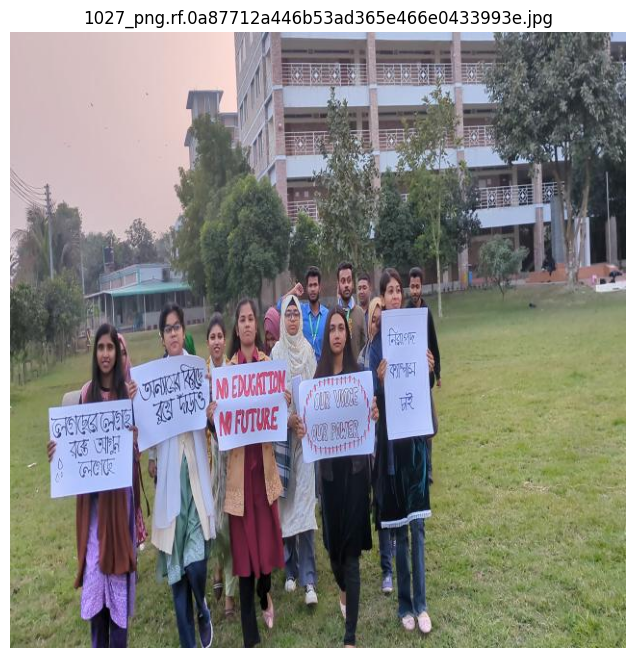

In [33]:
# View Missing Annotation Image

from PIL import Image
import matplotlib.pyplot as plt

if len(train_missing_ann):

    folder = TRAIN_DIR
    img = train_missing_ann[0]

elif len(valid_missing_ann):

    folder = VALID_DIR
    img = valid_missing_ann[0]

else:

    folder = TEST_DIR
    img = test_missing_ann[0]

img_path = os.path.join(folder, img["file_name"])

image = Image.open(img_path)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title(img["file_name"])

plt.show()

In [34]:
# Remove Images Without Annotation

for img in test_missing_ann:

    img_path = os.path.join(TEST_DIR, img["file_name"])

    if os.path.exists(img_path):

        os.remove(img_path)

        print(f"Removed : {img['file_name']}")

print("\nDataset cleaned successfully.")

Removed : 1027_png.rf.0a87712a446b53ad365e466e0433993e.jpg

Dataset cleaned successfully.


In [35]:
#Create Classification Dataset Directories

import os

CLASSIFICATION_ROOT = os.path.join(PROJECT_DIR, "classification_dataset")

SPLITS = ["train", "valid", "test"]
CLASSES = ["Fight", "Normal", "Poster"]

for split in SPLITS:

    for cls in CLASSES:

        folder = os.path.join(CLASSIFICATION_ROOT, split, cls)

        os.makedirs(folder, exist_ok=True)

print("=" * 70)
print("Classification directory structure created successfully.")
print("=" * 70)

Classification directory structure created successfully.


In [36]:
#Category Mapping

category_mapping = {}

for cat in categories:

    category_mapping[cat["id"]] = cat["name"]

print(category_mapping)

{0: 'suspicious', 1: 'Fight', 2: 'Normal', 3: 'Poster'}


In [37]:
#Image Label Assignment Strategy

def assign_image_label(category_names):

    category_names = list(set(category_names))

    if "Fight" in category_names:
        return "Fight"

    elif "Normal" in category_names:
        return "Normal"

    elif "Poster" in category_names:
        return "Poster"

    return None

In [38]:
# Convert COCO Split

import shutil
from collections import defaultdict

def convert_split(coco, image_dir, split_name):

    # Image ID → Category Names
    image_categories = defaultdict(list)

    for ann in coco.dataset["annotations"]:

        cat_name = category_mapping[ann["category_id"]]

        if cat_name != "suspicious":
            image_categories[ann["image_id"]].append(cat_name)

    copied = 0
    skipped = 0

    for img in coco.dataset["images"]:

        image_id = img["id"]

        if image_id not in image_categories:
            skipped += 1
            continue

        label = assign_image_label(image_categories[image_id])

        if label is None:
            skipped += 1
            continue

        src = os.path.join(image_dir, img["file_name"])

        dst = os.path.join(
            CLASSIFICATION_ROOT,
            split_name,
            label,
            img["file_name"]
        )

        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied += 1

    print(f"{split_name.upper()}")
    print(f"Copied Images : {copied}")
    print(f"Skipped Images: {skipped}")
    print("-"*60)

In [39]:
# Convert Complete Dataset

print("="*70)
print("Converting COCO Dataset to Classification Dataset")
print("="*70)

convert_split(train_coco, TRAIN_DIR, "train")
convert_split(valid_coco, VALID_DIR, "valid")
convert_split(test_coco, TEST_DIR, "test")

print("="*70)
print("Conversion Completed Successfully.")
print("="*70)

Converting COCO Dataset to Classification Dataset
TRAIN
Copied Images : 3656
Skipped Images: 0
------------------------------------------------------------
VALID
Copied Images : 348
Skipped Images: 0
------------------------------------------------------------
TEST
Copied Images : 173
Skipped Images: 1
------------------------------------------------------------
Conversion Completed Successfully.


In [40]:
# Verify Converted Dataset

def count_images(folder):

    total = 0

    for cls in CLASSES:

        path = os.path.join(folder, cls)

        total += len([
            f for f in os.listdir(path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ])

    return total

train_count = count_images(
    os.path.join(CLASSIFICATION_ROOT,"train")
)

valid_count = count_images(
    os.path.join(CLASSIFICATION_ROOT,"valid")
)

test_count = count_images(
    os.path.join(CLASSIFICATION_ROOT,"test")
)

print("="*70)
print("Classification Dataset Summary")
print("="*70)

print("Train :",train_count)
print("Valid :",valid_count)
print("Test  :",test_count)

Classification Dataset Summary
Train : 3656
Valid : 348
Test  : 173


In [41]:
# Class Distribution

summary = []

for split in SPLITS:

    for cls in CLASSES:

        folder = os.path.join(CLASSIFICATION_ROOT, split, cls)

        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ])

        summary.append([split, cls, count])

summary_df = pd.DataFrame(
    summary,
    columns=["Split","Class","Images"]
)

display(summary_df)

,Split,Class,Images
0,train,Fight,1883
1,train,Normal,1728
2,train,Poster,45
3,valid,Fight,174
4,valid,Normal,172
5,valid,Poster,2
6,test,Fight,85
7,test,Normal,85
8,test,Poster,3


In [42]:
#  Classification Dataset Path
CLASSIFICATION_ROOT = os.path.join(PROJECT_DIR, "classification_dataset")

SPLITS = ["train", "valid", "test"]

CLASSES = ["Fight", "Normal", "Poster"]

print("="*70)
print("Classification Dataset Loaded")
print("="*70)

Classification Dataset Loaded


In [43]:
# Number of Classes

print("="*70)
print("NUMBER OF CLASSES")
print("="*70)

print(f"Total Classes : {len(CLASSES)}")

print()

for i, cls in enumerate(CLASSES):

    print(f"Class {i} : {cls}")

NUMBER OF CLASSES
Total Classes : 3

Class 0 : Fight
Class 1 : Normal
Class 2 : Poster


In [44]:
#Images per Class

dataset_summary = []

for split in SPLITS:

    for cls in CLASSES:

        folder = os.path.join(
            CLASSIFICATION_ROOT,
            split,
            cls
        )

        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ])

        dataset_summary.append([
            split,
            cls,
            count
        ])

dataset_df = pd.DataFrame(

    dataset_summary,

    columns=[
        "Split",
        "Class",
        "Images"
    ]

)

display(dataset_df)

,Split,Class,Images
0,train,Fight,1883
1,train,Normal,1728
2,train,Poster,45
3,valid,Fight,174
4,valid,Normal,172
5,valid,Poster,2
6,test,Fight,85
7,test,Normal,85
8,test,Poster,3


In [45]:
# Dataset Distribution

distribution = (

    dataset_df

    .groupby("Split")["Images"]

    .sum()

    .reset_index()

)

distribution.columns = [

    "Dataset Split",
    "Total Images"

]

display(distribution)

,Dataset Split,Total Images
0,test,173
1,train,3656
2,valid,348


In [46]:
# Overall Class Distribution

overall_distribution = (

    dataset_df

    .groupby("Class")["Images"]

    .sum()

    .reset_index()

)

overall_distribution.columns = [

    "Class",
    "Total Images"

]

display(overall_distribution)

,Class,Total Images
0,Fight,2142
1,Normal,1985
2,Poster,50


In [47]:
# Class Imbalance Analysis

overall_distribution["Percentage"] = (

    overall_distribution["Total Images"]

    /

    overall_distribution["Total Images"].sum()

) * 100

overall_distribution["Percentage"] = (

    overall_distribution["Percentage"]

    .round(2)

)

display(overall_distribution)

,Class,Total Images,Percentage
0,Fight,2142,51.28
1,Normal,1985,47.52
2,Poster,50,1.20


In [48]:
# Imbalance Ratio

max_class = overall_distribution["Total Images"].max()

min_class = overall_distribution["Total Images"].min()

imbalance_ratio = max_class / min_class

print("="*70)
print("CLASS IMBALANCE ANALYSIS")
print("="*70)

print(f"Majority Class Size : {max_class}")
print(f"Minority Class Size : {min_class}")
print(f"Imbalance Ratio     : {imbalance_ratio:.2f}:1")

CLASS IMBALANCE ANALYSIS
Majority Class Size : 2142
Minority Class Size : 50
Imbalance Ratio     : 42.84:1


In [49]:
#  Dataset Summary

train_total = dataset_df[
    dataset_df["Split"] == "train"
]["Images"].sum()

valid_total = dataset_df[
    dataset_df["Split"] == "valid"
]["Images"].sum()

test_total = dataset_df[
    dataset_df["Split"] == "test"
]["Images"].sum()

print("="*70)
print("CLASSIFICATION DATASET SUMMARY")
print("="*70)

print(f"Total Classes      : {len(CLASSES)}")

print(f"Training Images    : {train_total}")
print(f"Validation Images  : {valid_total}")
print(f"Testing Images     : {test_total}")

print(f"Total Images       : {train_total + valid_total + test_total}")

print()

print("Class Distribution")

display(overall_distribution)

print("="*70)

if imbalance_ratio > 10:

    print("Dataset is Highly Imbalanced")

elif imbalance_ratio > 3:

    print("Dataset is Moderately Imbalanced")

else:

    print("Dataset is Relatively Balanced")

CLASSIFICATION DATASET SUMMARY
Total Classes      : 3
Training Images    : 3656
Validation Images  : 348
Testing Images     : 173
Total Images       : 4177

Class Distribution


,Class,Total Images,Percentage
0,Fight,2142,51.28
1,Normal,1985,47.52
2,Poster,50,1.20


Dataset is Highly Imbalanced


In [50]:
# Import Libraries

import torch
import torchvision

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

from sklearn.utils.class_weight import compute_class_weight

import numpy as np

print("="*70)
print("Libraries Imported Successfully.")
print("="*70)

Libraries Imported Successfully.


In [51]:
#Dataset Paths

TRAIN_PATH = os.path.join(CLASSIFICATION_ROOT, "train")
VALID_PATH = os.path.join(CLASSIFICATION_ROOT, "valid")
TEST_PATH  = os.path.join(CLASSIFICATION_ROOT, "test")

print(TRAIN_PATH)
print(VALID_PATH)
print(TEST_PATH)

/content/drive/MyDrive/Suspicious_behavior/data/classification_dataset/train
/content/drive/MyDrive/Suspicious_behavior/data/classification_dataset/valid
/content/drive/MyDrive/Suspicious_behavior/data/classification_dataset/test


In [52]:
# Training Transform
IMAGE_SIZE = 224

train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]

    )

])

print("Training Transform Ready")

Training Transform Ready


In [53]:
# Validation/Test Transform

test_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]

    )

])

print("Validation/Test Transform Ready")

Validation/Test Transform Ready


In [54]:
# Create Dataset

train_dataset = datasets.ImageFolder(
    TRAIN_PATH,
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    VALID_PATH,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_PATH,
    transform=test_transform
)

print("="*70)
print("Dataset Loaded Successfully")
print("="*70)

print("Train :",len(train_dataset))
print("Valid :",len(valid_dataset))
print("Test  :",len(test_dataset))

Dataset Loaded Successfully
Train : 3656
Valid : 348
Test  : 173


In [55]:
#Class Mapping

print("="*70)
print("Class Mapping")
print("="*70)

print(train_dataset.class_to_idx)

idx_to_class = {

    value:key

    for key,value in train_dataset.class_to_idx.items()

}

print(idx_to_class)

Class Mapping
{'Fight': 0, 'Normal': 1, 'Poster': 2}
{0: 'Fight', 1: 'Normal', 2: 'Poster'}


In [56]:
# Compute Class Weights

labels = train_dataset.targets

classes = np.unique(labels)

weights = compute_class_weight(

    class_weight="balanced",

    classes=classes,

    y=labels

)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32
)

print("="*70)
print("Computed Class Weights")
print("="*70)

for i,w in enumerate(class_weights):

    print(f"{idx_to_class[i]} : {w:.4f}")

Computed Class Weights
Fight : 0.6472
Normal : 0.7052
Poster : 27.0815


In [57]:
#Weighted CrossEntropyLoss

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class_weights = class_weights.to(DEVICE)

criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights
)

print("="*70)
print("Weighted CrossEntropyLoss Ready")
print("="*70)

Weighted CrossEntropyLoss Ready


In [58]:
#  Create DataLoaders

BATCH_SIZE = CONFIG["BATCH_SIZE"]

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True

)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

print("="*70)
print("DataLoaders Created Successfully")
print("="*70)

DataLoaders Created Successfully


In [59]:
# Final Verification

images, labels = next(iter(train_loader))

print("="*70)
print("TRAINING DATA READY")
print("="*70)

print("Image Batch Shape :", images.shape)
print("Label Shape       :", labels.shape)

print()

print("Number of Classes :", len(train_dataset.classes))

print("Class Names       :", train_dataset.classes)

print()

print("Training Samples  :", len(train_dataset))
print("Validation Samples:", len(valid_dataset))
print("Testing Samples   :", len(test_dataset))

TRAINING DATA READY
Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Shape       : torch.Size([32])

Number of Classes : 3
Class Names       : ['Fight', 'Normal', 'Poster']

Training Samples  : 3656
Validation Samples: 348
Testing Samples   : 173


In [60]:
#Import Libraries

import copy
import time
import numpy as np

import torch
import torch.nn as nn

import torchvision.models as models

from tqdm.auto import tqdm

print("=" * 70)
print("CNN-LSTM Libraries Imported Successfully")
print("=" * 70)

CNN-LSTM Libraries Imported Successfully


In [61]:
# Device Configuration

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("Device Configuration")
print("=" * 70)

print("Device :", DEVICE)

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

else:

    print("Running on CPU")

Device Configuration
Device : cuda
GPU : Tesla T4


In [62]:
# Hyperparameters

CNN_BACKBONE = "ResNet18"

FEATURE_DIM = 512

LSTM_HIDDEN = 256

LSTM_LAYERS = 2

BIDIRECTIONAL = True

DROPOUT = 0.5

NUM_CLASSES = 3

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

NUM_EPOCHS = 30

PATIENCE = 5

print("=" * 70)
print("Hyperparameters Initialized")
print("=" * 70)

Hyperparameters Initialized


In [63]:
# Load Pretrained ResNet18

from torchvision.models import resnet18, ResNet18_Weights

# Load ImageNet pretrained ResNet18
cnn_backbone = resnet18(
    weights=ResNet18_Weights.IMAGENET1K_V1
)

print("=" * 70)
print("Pretrained ResNet18 Loaded Successfully")
print("=" * 70)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]


Pretrained ResNet18 Loaded Successfully


In [64]:
# Remove Classification Layer

cnn_backbone = nn.Sequential(
    *list(cnn_backbone.children())[:-2]
)

print(cnn_backbone)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [65]:
# Freeze CNN Parameters

for param in cnn_backbone.parameters():
    param.requires_grad = False

print("=" * 70)
print("CNN Backbone Frozen")
print("=" * 70)

CNN Backbone Frozen


In [66]:
# Move Backbone to Device

cnn_backbone = cnn_backbone.to(DEVICE)

print("=" * 70)
print("CNN Backbone moved to", DEVICE)
print("=" * 70)

CNN Backbone moved to cuda


In [67]:
# Verify Feature Map Shape

cnn_backbone.eval()

dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

with torch.no_grad():

    feature_map = cnn_backbone(dummy)

print("=" * 70)
print("Feature Map Shape")
print("=" * 70)

print(feature_map.shape)

Feature Map Shape
torch.Size([1, 512, 7, 7])


In [68]:
# Convert Feature Map to Sequence
sequence = feature_map.flatten(2)
sequence = sequence.permute(0, 2, 1)

print("=" * 70)
print("Feature Sequence Shape")
print("=" * 70)

print(sequence.shape)

Feature Sequence Shape
torch.Size([1, 49, 512])


In [69]:
#CNN-LSTM Model

class CNNLSTM(nn.Module):

    def __init__(self,
                 num_classes=3,
                 hidden_size=256,
                 num_layers=2,
                 dropout=0.5):

        super(CNNLSTM, self).__init__()

        # --------------------------------------------------
        # CNN Backbone
        # --------------------------------------------------

        backbone = models.resnet18(
            weights=ResNet18_Weights.IMAGENET1K_V1
        )

        self.cnn = nn.Sequential(
            *list(backbone.children())[:-2]
        )

        # Freeze CNN

        for param in self.cnn.parameters():

            param.requires_grad = False

        # --------------------------------------------------
        # Bi-LSTM
        # --------------------------------------------------

        self.lstm = nn.LSTM(

            input_size=512,

            hidden_size=hidden_size,

            num_layers=num_layers,

            batch_first=True,

            bidirectional=True

        )

        # --------------------------------------------------
        # Dropout
        # --------------------------------------------------

        self.dropout = nn.Dropout(dropout)

        # --------------------------------------------------
        # Fully Connected
        # --------------------------------------------------

        self.fc = nn.Linear(

            hidden_size * 2,

            num_classes

        )

    def forward(self, x):

        # ----------------------------------------------
        # CNN Feature Extraction
        # ----------------------------------------------

        features = self.cnn(x)

        # B × 512 × 7 × 7

        # ----------------------------------------------
        # Feature Sequence
        # ----------------------------------------------

        features = features.flatten(2)

        features = features.permute(0,2,1)

        # B × 49 × 512

        # ----------------------------------------------
        # LSTM
        # ----------------------------------------------

        output, (hidden, cell) = self.lstm(features)

        # ----------------------------------------------
        # Forward + Backward Hidden
        # ----------------------------------------------

        forward_hidden = hidden[-2]

        backward_hidden = hidden[-1]

        hidden = torch.cat(

            (forward_hidden, backward_hidden),

            dim=1

        )

        # ----------------------------------------------
        # Dropout
        # ----------------------------------------------

        hidden = self.dropout(hidden)

        # ----------------------------------------------
        # Classification
        # ----------------------------------------------

        logits = self.fc(hidden)

        return logits

In [70]:
# Initialize CNN-LSTM

model = CNNLSTM(

    num_classes=NUM_CLASSES,

    hidden_size=LSTM_HIDDEN,

    num_layers=LSTM_LAYERS,

    dropout=DROPOUT

)

model = model.to(DEVICE)

print("="*70)
print("CNN-LSTM Initialized Successfully")
print("="*70)

CNN-LSTM Initialized Successfully


In [71]:
# Model Summary

print(model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

In [72]:
# Forward Pass Verification
dummy = torch.randn(

    2,

    3,

    224,

    224

).to(DEVICE)

with torch.no_grad():

    outputs = model(dummy)

print("="*70)
print("Forward Pass Successful")
print("="*70)

print("Output Shape :", outputs.shape)

Forward Pass Successful
Output Shape : torch.Size([2, 3])


In [73]:
# Model Parameters

total_params = sum(

    p.numel()

    for p in model.parameters()

)

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

print("="*70)

print("MODEL INFORMATION")

print("="*70)

print(f"Total Parameters      : {total_params:,}")

print(f"Trainable Parameters  : {trainable_params:,}")

print(f"Frozen Parameters     : {total_params-trainable_params:,}")

print("="*70)

MODEL INFORMATION
Total Parameters      : 14,331,971
Trainable Parameters  : 3,155,459
Frozen Parameters     : 11,176,512


In [74]:
#Loss Function

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("=" * 70)
print("Weighted CrossEntropyLoss Initialized")
print("=" * 70)

Weighted CrossEntropyLoss Initialized


In [75]:
#Optimizer

optimizer = torch.optim.AdamW(

    filter(lambda p: p.requires_grad, model.parameters()),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)

print("=" * 70)
print("AdamW Optimizer Initialized")
print("=" * 70)

AdamW Optimizer Initialized


In [76]:
#Learning Rate Scheduler

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2,

    min_lr=1e-6

)

print("=" * 70)
print("ReduceLROnPlateau Scheduler Ready")
print("=" * 70)

ReduceLROnPlateau Scheduler Ready


In [77]:
# Early Stopping

class EarlyStopping:

    def __init__(self, patience=5):

        self.patience = patience

        self.counter = 0

        self.best_loss = np.inf

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            print(f"EarlyStopping Counter : {self.counter}/{self.patience}")

            if self.counter >= self.patience:

                self.stop = True


early_stopping = EarlyStopping(
    patience=PATIENCE
)

print("=" * 70)
print("Early Stopping Initialized")
print("=" * 70)

Early Stopping Initialized


In [78]:
# Mixed Precision

from torch.cuda.amp import GradScaler

USE_AMP = torch.cuda.is_available()

scaler = GradScaler(enabled=USE_AMP)

print("=" * 70)
print("Automatic Mixed Precision")
print("=" * 70)

print("Enabled :", USE_AMP)

Automatic Mixed Precision
Enabled : True


In [79]:
#Train One Epoch

from torch.cuda.amp import autocast

def train_one_epoch(model,
                    loader,
                    criterion,
                    optimizer,
                    scaler,
                    device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast(enabled=USE_AMP):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [80]:
# Validation One Epoch

def validate_one_epoch(model,
                       loader,
                       criterion,
                       device):

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in tqdm(loader, leave=False):

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [81]:
# CNN-LSTM Training

history = {

    "train_loss": [],

    "train_acc": [],

    "val_loss": [],

    "val_acc": []

}

best_val_loss = np.inf

SAVE_PATH = os.path.join(

    MODEL_DIR,

    "best_cnn_lstm.pth"

)

print("=" * 70)
print("Training Started...")
print("=" * 70)

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

    train_loss, train_acc = train_one_epoch(

        model,

        train_loader,

        criterion,

        optimizer,

        scaler,

        DEVICE

    )

    val_loss, val_acc = validate_one_epoch(

        model,

        valid_loader,

        criterion,

        DEVICE

    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)

    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)

    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Val Acc    : {val_acc:.4f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(

            model.state_dict(),

            SAVE_PATH

        )

        print("Best Model Saved")

    early_stopping(val_loss)

    if early_stopping.stop:

        print("\nEarly Stopping Triggered.")

        break

training_time = time.time() - start_time

print("=" * 70)
print("Training Completed")
print("=" * 70)

print(f"Training Time : {training_time/60:.2f} Minutes")

print(f"Best Validation Loss : {best_val_loss:.4f}")

Training Started...

Epoch [1/30]


  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

Train Loss : 0.6739
Train Acc  : 0.9188
Val Loss   : 0.3328
Val Acc    : 0.9540
Best Model Saved

Epoch [2/30]


  0%|          | 0/115 [00:00<?, ?it/s]

...

  0%|          | 0/11 [00:00<?, ?it/s]

Train Loss : 0.3095
Train Acc  : 0.8972
Val Loss   : 0.2691
Val Acc    : 0.8247
EarlyStopping Counter : 4/5

Epoch [7/30]


  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

Train Loss : 0.3037
Train Acc  : 0.8961
Val Loss   : 0.3006
Val Acc    : 0.7931
EarlyStopping Counter : 5/5

Early Stopping Triggered.
Training Completed
Training Time : 7.49 Minutes
Best Validation Loss : 0.2497


In [82]:
# Load Best Model

model.load_state_dict(

    torch.load(

        SAVE_PATH,

        map_location=DEVICE

    )

)

model.eval()

print("=" * 70)
print("Best CNN-LSTM Model Loaded Successfully")
print("=" * 70)

Best CNN-LSTM Model Loaded Successfully


In [83]:
#Import Evaluation Libraries

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report

)

print("="*70)
print("Evaluation Libraries Loaded")
print("="*70)

Evaluation Libraries Loaded


In [84]:
# Load Best Model

model.load_state_dict(

    torch.load(

        SAVE_PATH,

        map_location=DEVICE

    )

)

model.eval()

print("="*70)
print("Best CNN-LSTM Model Loaded")
print("="*70)

Best CNN-LSTM Model Loaded


In [85]:
# Test Prediction

all_labels = []

all_predictions = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)

        outputs = model(images)

        _, predictions = torch.max(outputs,1)

        all_labels.extend(

            labels.cpu().numpy()

        )

        all_predictions.extend(

            predictions.cpu().numpy()

        )

print("="*70)
print("Inference Completed")
print("="*70)

  0%|          | 0/6 [00:00<?, ?it/s]

Inference Completed


In [86]:
# Performance Metrics

accuracy = accuracy_score(

    all_labels,

    all_predictions

)

precision = precision_score(

    all_labels,

    all_predictions,

    average="weighted",

    zero_division=0

)

recall = recall_score(

    all_labels,

    all_predictions,

    average="weighted",

    zero_division=0

)

f1 = f1_score(

    all_labels,

    all_predictions,

    average="weighted",

    zero_division=0

)

print("="*70)

print("CNN-LSTM TEST PERFORMANCE")

print("="*70)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-score  : {f1:.4f}")

print("="*70)

CNN-LSTM TEST PERFORMANCE
Accuracy  : 0.9306
Precision : 0.9170
Recall    : 0.9306
F1-score  : 0.9220


In [87]:
# Confusion Matrix

cm = confusion_matrix(

    all_labels,

    all_predictions

)

cm_df = pd.DataFrame(

    cm,

    index=train_dataset.classes,

    columns=train_dataset.classes

)

display(cm_df)

,Fight,Normal,Poster
Fight,85,0,0
Normal,9,76,0
Poster,0,3,0


In [88]:
#Classification Report

report = classification_report(

    all_labels,

    all_predictions,

    target_names=train_dataset.classes,

    output_dict=True,

    zero_division=0

)

report_df = pd.DataFrame(report).transpose()

display(report_df)

,precision,recall,f1-score,support
Fight,0.904255,1.000000,0.949721,85.000000
Normal,0.962025,0.894118,0.926829,85.000000
Poster,0.000000,0.000000,0.000000,3.000000
accuracy,0.930636,0.930636,0.930636,0.930636
macro avg,0.622094,0.631373,0.625517,173.000000
weighted avg,0.916959,0.930636,0.922004,173.000000


In [89]:
#Per-Class Performance

per_class = report_df.loc[

    train_dataset.classes,

    [

        "precision",

        "recall",

        "f1-score",

        "support"

    ]

]

display(per_class)

,precision,recall,f1-score,support
Fight,0.904255,1.000000,0.949721,85.0
Normal,0.962025,0.894118,0.926829,85.0
Poster,0.000000,0.000000,0.000000,3.0


In [90]:
# Save Evaluation Results

results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

RESULT_FILE = os.path.join(

    RESULT_DIR,

    "cnn_lstm_results.csv"

)

results.to_csv(

    RESULT_FILE,

    index=False

)

print("="*70)

print("Results Saved Successfully")

print(RESULT_FILE)

print("="*70)

Results Saved Successfully
/content/drive/MyDrive/Suspicious_behavior/data/results/cnn_lstm_results.csv


In [91]:
# Evaluation Summary

summary = pd.DataFrame({

    "Model":[

        "CNN + LSTM"

    ],

    "Accuracy":[

        accuracy

    ],

    "Precision":[

        precision

    ],

    "Recall":[

        recall

    ],

    "F1-score":[

        f1

    ]

})

display(summary)

,Model,Accuracy,Precision,Recall,F1-score
0,CNN + LSTM,0.930636,0.916959,0.930636,0.922004


In [92]:
# Import Libraries

import timm

import copy

import time

print("="*70)
print("Vision Transformer Libraries Imported")
print("="*70)

Vision Transformer Libraries Imported


In [93]:
# Hyperparameters

VIT_MODEL = "vit_base_patch16_224"

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

NUM_CLASSES = 3

NUM_EPOCHS = 30

PATIENCE = 5

print("="*70)
print("ViT Hyperparameters Ready")
print("="*70)

ViT Hyperparameters Ready


In [94]:
#  Load Pretrained ViT

vit_model = timm.create_model(

    VIT_MODEL,

    pretrained=True

)

print("="*70)
print("Pretrained Vision Transformer Loaded")
print("="*70)

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Pretrained Vision Transformer Loaded


In [95]:
# Replace Classification Head

in_features = vit_model.head.in_features

vit_model.head = nn.Linear(

    in_features,

    NUM_CLASSES

)

print("="*70)
print("Classification Head Replaced")
print("="*70)

Classification Head Replaced


In [96]:
# Initialize Model

vit_model = vit_model.to(DEVICE)

print("="*70)
print("Vision Transformer Ready")
print("="*70)

Vision Transformer Ready


In [97]:
# Verify Model

dummy = torch.randn(

    2,

    3,

    224,

    224

).to(DEVICE)

with torch.no_grad():

    outputs = vit_model(dummy)

print("="*70)
print("Forward Pass Successful")
print("="*70)

print(outputs.shape)

Forward Pass Successful
torch.Size([2, 3])


In [98]:
#  Model Parameters

total = sum(

    p.numel()

    for p in vit_model.parameters()

)

trainable = sum(

    p.numel()

    for p in vit_model.parameters()

    if p.requires_grad

)

print("="*70)

print("ViT MODEL SUMMARY")

print("="*70)

print(f"Total Parameters     : {total:,}")

print(f"Trainable Parameters : {trainable:,}")

print("="*70)

ViT MODEL SUMMARY
Total Parameters     : 85,800,963
Trainable Parameters : 85,800,963


In [99]:
#Loss Function

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("=" * 70)
print("Weighted CrossEntropyLoss Initialized")
print("=" * 70)

Weighted CrossEntropyLoss Initialized


In [100]:
# Optimizer

optimizer = torch.optim.AdamW(

    vit_model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)

print("=" * 70)
print("AdamW Optimizer Initialized")
print("=" * 70)

AdamW Optimizer Initialized


In [101]:
# Learning Rate Scheduler

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2,

    min_lr=1e-6

)

print("=" * 70)
print("ReduceLROnPlateau Scheduler Ready")
print("=" * 70)

ReduceLROnPlateau Scheduler Ready


In [102]:
#Early Stopping

early_stopping = EarlyStopping(
    patience=PATIENCE
)

print("=" * 70)
print("Early Stopping Initialized")
print("=" * 70)

Early Stopping Initialized


In [103]:
#  ViT Training

history_vit = {

    "train_loss": [],
    "train_acc": [],

    "val_loss": [],
    "val_acc": []

}

best_val_loss = np.inf

SAVE_PATH_VIT = os.path.join(

    MODEL_DIR,

    "best_vit.pth"

)

print("=" * 70)
print("Vision Transformer Training Started")
print("=" * 70)

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

    train_loss, train_acc = train_one_epoch(

        vit_model,

        train_loader,

        criterion,

        optimizer,

        scaler,

        DEVICE

    )

    val_loss, val_acc = validate_one_epoch(

        vit_model,

        valid_loader,

        criterion,

        DEVICE

    )

    scheduler.step(val_loss)

    history_vit["train_loss"].append(train_loss)
    history_vit["train_acc"].append(train_acc)

    history_vit["val_loss"].append(val_loss)
    history_vit["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(

            vit_model.state_dict(),

            SAVE_PATH_VIT

        )

        print("Best Model Saved")

    early_stopping(val_loss)

    if early_stopping.stop:

        print("\nEarly Stopping Triggered.")

        break

training_time = time.time() - start_time

print("=" * 70)
print("Training Completed")
print("=" * 70)

print(f"Training Time : {training_time/60:.2f} Minutes")

print(f"Best Validation Loss : {best_val_loss:.4f}")

Vision Transformer Training Started

Epoch [1/30]


  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

Train Loss : 0.8476
Train Acc  : 0.7831
Val Loss   : 0.3157
Val Acc    : 0.9540
Best Model Saved

Epoch [2/30]


  0%|          | 0/115 [00:00<?, ?it/s]

...

  0%|          | 0/11 [00:00<?, ?it/s]

Train Loss : 0.2720
Train Acc  : 0.8961
Val Loss   : 0.2564
Val Acc    : 0.8247
EarlyStopping Counter : 4/5

Epoch [17/30]


  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

Train Loss : 0.2727
Train Acc  : 0.8947
Val Loss   : 0.2182
Val Acc    : 0.9425
EarlyStopping Counter : 5/5

Early Stopping Triggered.
Training Completed
Training Time : 21.07 Minutes
Best Validation Loss : 0.1981


In [104]:
# Load Best ViT Model

vit_model.load_state_dict(

    torch.load(

        SAVE_PATH_VIT,

        map_location=DEVICE

    )

)

vit_model.eval()

print("=" * 70)
print("Best Vision Transformer Loaded")
print("=" * 70)

Best Vision Transformer Loaded


In [105]:
# Test Prediction

vit_labels = []

vit_predictions = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)

        outputs = vit_model(images)

        _, predicted = torch.max(outputs,1)

        vit_labels.extend(labels.cpu().numpy())

        vit_predictions.extend(predicted.cpu().numpy())

print("="*70)
print("Inference Completed")
print("="*70)

  0%|          | 0/6 [00:00<?, ?it/s]

Inference Completed


In [106]:
# Performance Metrics

vit_accuracy = accuracy_score(

    vit_labels,

    vit_predictions

)

vit_precision = precision_score(

    vit_labels,

    vit_predictions,

    average="weighted",

    zero_division=0

)

vit_recall = recall_score(

    vit_labels,

    vit_predictions,

    average="weighted",

    zero_division=0

)

vit_f1 = f1_score(

    vit_labels,

    vit_predictions,

    average="weighted",

    zero_division=0

)

print("="*70)

print("VISION TRANSFORMER TEST PERFORMANCE")

print("="*70)

print(f"Accuracy  : {vit_accuracy:.4f}")

print(f"Precision : {vit_precision:.4f}")

print(f"Recall    : {vit_recall:.4f}")

print(f"F1-score  : {vit_f1:.4f}")

print("="*70)

VISION TRANSFORMER TEST PERFORMANCE
Accuracy  : 0.9653
Precision : 0.9486
Recall    : 0.9653
F1-score  : 0.9568


In [107]:
# Confusion Matrix
vit_cm = confusion_matrix(

    vit_labels,

    vit_predictions

)

vit_cm_df = pd.DataFrame(

    vit_cm,

    index=train_dataset.classes,

    columns=train_dataset.classes

)

display(vit_cm_df)

,Fight,Normal,Poster
Fight,85,0,0
Normal,3,82,0
Poster,0,3,0


In [108]:
#  Classification Report

vit_report = classification_report(

    vit_labels,

    vit_predictions,

    target_names=train_dataset.classes,

    output_dict=True,

    zero_division=0

)

vit_report_df = pd.DataFrame(vit_report).transpose()

display(vit_report_df)

,precision,recall,f1-score,support
Fight,0.965909,1.000000,0.982659,85.000000
Normal,0.964706,0.964706,0.964706,85.000000
Poster,0.000000,0.000000,0.000000,3.000000
accuracy,0.965318,0.965318,0.965318,0.965318
macro avg,0.643538,0.654902,0.649122,173.000000
weighted avg,0.948568,0.965318,0.956798,173.000000


In [109]:
# Per-Class Performance

vit_per_class = vit_report_df.loc[

    train_dataset.classes,

    [

        "precision",

        "recall",

        "f1-score",

        "support"

    ]

]

display(vit_per_class)

,precision,recall,f1-score,support
Fight,0.965909,1.000000,0.982659,85.0
Normal,0.964706,0.964706,0.964706,85.0
Poster,0.000000,0.000000,0.000000,3.0


In [110]:
#  Save Results

vit_results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score"

    ],

    "Value":[

        vit_accuracy,

        vit_precision,

        vit_recall,

        vit_f1

    ]

})

VIT_RESULT_FILE = os.path.join(

    RESULT_DIR,

    "vit_results.csv"

)

vit_results.to_csv(

    VIT_RESULT_FILE,

    index=False

)

print("="*70)

print("Results Saved Successfully")

print(VIT_RESULT_FILE)

print("="*70)

Results Saved Successfully
/content/drive/MyDrive/Suspicious_behavior/data/results/vit_results.csv


In [111]:
# Vision Transformer Summary

vit_summary = pd.DataFrame({

    "Model":[

        "Vision Transformer"

    ],

    "Accuracy":[

        vit_accuracy

    ],

    "Precision":[

        vit_precision

    ],

    "Recall":[

        vit_recall

    ],

    "F1-score":[

        vit_f1

    ]

})

display(vit_summary)

,Model,Accuracy,Precision,Recall,F1-score
0,Vision Transformer,0.965318,0.948568,0.965318,0.956798


In [112]:
# Import Libraries

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

import joblib

print("=" * 70)
print("Libraries Imported Successfully")
print("=" * 70)

Libraries Imported Successfully


In [113]:
# Load ResNet18 Feature Extractor

from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights

feature_extractor = resnet18(
    weights=ResNet18_Weights.IMAGENET1K_V1
)

feature_extractor.fc = nn.Identity()

feature_extractor = feature_extractor.to(DEVICE)

feature_extractor.eval()

print("=" * 70)
print("Feature Extractor Ready")
print("=" * 70)

Feature Extractor Ready


In [114]:
# Section 11.3 - Feature Extraction Function

def extract_features(model, loader):

    features = []

    labels = []

    model.eval()

    with torch.no_grad():

        for images, target in tqdm(loader):

            images = images.to(DEVICE)

            output = model(images)

            features.append(
                output.cpu().numpy()
            )

            labels.append(
                target.numpy()
            )

    features = np.concatenate(features)

    labels = np.concatenate(labels)

    return features, labels

In [115]:
# Extract Deep Features

print("=" * 70)
print("Extracting Training Features")
print("=" * 70)

X_train, y_train = extract_features(
    feature_extractor,
    train_loader
)

print("=" * 70)
print("Extracting Test Features")
print("=" * 70)

X_test, y_test = extract_features(
    feature_extractor,
    test_loader
)

print()

print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape :", X_test.shape)

Extracting Training Features


  0%|          | 0/115 [00:00<?, ?it/s]

Extracting Test Features


  0%|          | 0/6 [00:00<?, ?it/s]


Training Feature Shape : (3656, 512)
Testing Feature Shape : (173, 512)


In [116]:
#  Feature Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("=" * 70)
print("Feature Scaling Completed")
print("=" * 70)

Feature Scaling Completed


In [117]:
# Train SVM

svm = SVC(

    kernel="rbf",

    C=1.0,

    gamma="scale",

    class_weight="balanced",

    random_state=SEED

)

print("=" * 70)
print("Training SVM...")
print("=" * 70)

svm.fit(X_train, y_train)

print("Training Completed")

Training SVM...
Training Completed


In [118]:
#  Test Prediction

svm_predictions = svm.predict(X_test)

print("=" * 70)
print("Prediction Completed")
print("=" * 70)

Prediction Completed


In [119]:
# SVM Evaluation

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

print("=" * 70)

print("CNN Feature + SVM Performance")

print("=" * 70)

print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1-score  : {svm_f1:.4f}")

CNN Feature + SVM Performance
Accuracy  : 0.9595
Precision : 0.9430
Recall    : 0.9595
F1-score  : 0.9510


In [120]:
#  Save Models

joblib.dump(

    svm,

    os.path.join(
        MODEL_DIR,
        "svm_model.pkl"
    )

)

joblib.dump(

    scaler,

    os.path.join(
        MODEL_DIR,
        "feature_scaler.pkl"
    )

)

print("=" * 70)
print("SVM Model Saved Successfully")
print("=" * 70)

SVM Model Saved Successfully


In [121]:
# Collect Model Results

comparison = pd.DataFrame({

    "Model":[

        "CNN + Bi-LSTM",

        "Vision Transformer",

        "CNN Feature + SVM"

    ],

    "Accuracy":[

        accuracy,

        vit_accuracy,

        svm_accuracy

    ],

    "Precision":[

        precision,

        vit_precision,

        svm_precision

    ],

    "Recall":[

        recall,

        vit_recall,

        svm_recall

    ],

    "F1-score":[

        f1,

        vit_f1,

        svm_f1

    ]

})

display(comparison)

,Model,Accuracy,Precision,Recall,F1-score
0,CNN + Bi-LSTM,0.930636,0.916959,0.930636,0.922004
1,Vision Transformer,0.965318,0.948568,0.965318,0.956798
2,CNN Feature + SVM,0.959538,0.943029,0.959538,0.951013


In [122]:
# Section 12.2 - Model Ranking

ranking = comparison.sort_values(

    by="Accuracy",

    ascending=False

).reset_index(drop=True)

ranking.index += 1

display(ranking)

,Model,Accuracy,Precision,Recall,F1-score
1,Vision Transformer,0.965318,0.948568,0.965318,0.956798
2,CNN Feature + SVM,0.959538,0.943029,0.959538,0.951013
3,CNN + Bi-LSTM,0.930636,0.916959,0.930636,0.922004


In [123]:
# Best Model

best = ranking.iloc[0]

print("="*70)

print("BEST PERFORMING MODEL")

print("="*70)

print(f"Model      : {best['Model']}")

print(f"Accuracy   : {best['Accuracy']:.4f}")

print(f"Precision  : {best['Precision']:.4f}")

print(f"Recall     : {best['Recall']:.4f}")

print(f"F1-score   : {best['F1-score']:.4f}")

BEST PERFORMING MODEL
Model      : Vision Transformer
Accuracy   : 0.9653
Precision  : 0.9486
Recall     : 0.9653
F1-score   : 0.9568


In [124]:
# Performance Difference

comparison["Accuracy (%)"] = comparison["Accuracy"]*100

comparison["Precision (%)"] = comparison["Precision"]*100

comparison["Recall (%)"] = comparison["Recall"]*100

comparison["F1-score (%)"] = comparison["F1-score"]*100

display(

    comparison[

        [

            "Model",

            "Accuracy (%)",

            "Precision (%)",

            "Recall (%)",

            "F1-score (%)"

        ]

    ]

)

,Model,Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,CNN + Bi-LSTM,93.063584,91.695869,93.063584,92.200431
1,Vision Transformer,96.531792,94.856805,96.531792,95.679775
2,CNN Feature + SVM,95.953757,94.302925,95.953757,95.101310


In [125]:
# Save Comparison

comparison.to_csv(

    os.path.join(

        RESULT_DIR,

        "final_model_comparison.csv"

    ),

    index=False

)

print("="*70)

print("Comparison Saved Successfully")

print("="*70)

Comparison Saved Successfully
